# Evaluation of AI Models as Learning Assistants

## Project Overview

This project evaluates four AI models—ChatGPT, Claude, Grok, and Qwen—as learning assistants for lower-division college courses in Statistics, Mathematics, and Python programming.

The benchmark contains 30 questions: 10 Statistics questions, 10 Mathematics questions, and 10 Python / Introductory Computer Science questions. Each model answered the same 30 questions, producing 120 responses in total. Questions were administered sequentially within a single conversation for each model, with conversation context retained between questions. Q1–Q2 and Q18–Q19 are documented as linked question sequences.

Each response is evaluated using four criteria:

1. Accuracy
2. Reasoning Completeness
3. Explanation Clarity
4. Tutoring Effectiveness

This notebook validates the dataset and compares model performance across evaluation criteria, subjects, and difficulty levels. It also examines error patterns and learning behaviors.

The primary analysis uses ratings from one primary rater, with an independent second-rater evaluation conducted on a subset of 32 responses to assess inter-rater reliability.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if os.path.basename(os.getcwd()) == "notebook":
    os.chdir("..")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 140)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the public-safe analysis dataset
responses = pd.read_csv("data/public_analysis_scores.csv")

# Reconstruct question-level metadata from the public dataset
questions = (
    responses[
        ["question_id", "question_type", "difficulty_level"]
    ]
    .drop_duplicates()
    .sort_values("question_id")
    .reset_index(drop=True)
)

# Detect fully blank rows
blank_question_rows = questions.isna().all(axis=1).sum()
blank_response_rows = responses.isna().all(axis=1).sum()

assert blank_question_rows == 0, (
    f"Found {blank_question_rows} fully blank row(s) in question metadata."
)

assert blank_response_rows == 0, (
    f"Found {blank_response_rows} fully blank row(s) in public_analysis_scores.csv."
)

print("Questions shape:", questions.shape)
print("Responses shape:", responses.shape)
print("Fully blank question rows:", blank_question_rows)
print("Fully blank response rows:", blank_response_rows)

Questions shape: (30, 3)
Responses shape: (120, 18)
Fully blank question rows: 0
Fully blank response rows: 0


In [3]:
print("Questions columns:")
print(questions.columns.tolist())

print("\nResponses columns:")
print(responses.columns.tolist())

Questions columns:
['question_id', 'question_type', 'difficulty_level']

Responses columns:
['question_id', 'question_type', 'difficulty_level', 'model_name', 'accuracy_score', 'reasoning_completeness_score', 'explanation_clarity_score', 'tutoring_effectiveness_score', 'overall_score', 'error_type', 'subject_specific_error', 'severity_level', 'overconfident_wrong_flag', 'learning_transfer_support', 'misconception_awareness', 'self_check_support', 'confidence_calibration', 'cognitive_load_level']


## 1. Data Preparation and Validation

### 1.1 Final Data Validation

This section checks whether the dataset contains 30 unique questions and 120 complete model responses.

In [4]:
print("Number of question rows:", len(questions))
print("Number of response rows:", len(responses))

print("Unique question IDs in questions:", questions["question_id"].nunique())
print("Unique question IDs in responses:", responses["question_id"].nunique())

print("Number of models:", responses["model_name"].nunique())

Number of question rows: 30
Number of response rows: 120
Unique question IDs in questions: 30
Unique question IDs in responses: 30
Number of models: 4


In [5]:
responses["model_name"].value_counts(dropna=False)

model_name
ChatGPT    30
Claude     30
Grok       30
Qwen       30
Name: count, dtype: int64

In [6]:
print("Questions per subject:")
print(questions["question_type"].value_counts())

print("\nQuestions per difficulty level:")
print(questions["difficulty_level"].value_counts())

Questions per subject:
question_type
Statistics                                10
Mathematics                               10
Python / Introductory Computer Science    10
Name: count, dtype: int64

Questions per difficulty level:
difficulty_level
medium    11
easy      10
hard       9
Name: count, dtype: int64


In [7]:
model_count_per_question = (
    responses.groupby("question_id")["model_name"].nunique()
)

invalid_questions = model_count_per_question[
    model_count_per_question != 4
]

if invalid_questions.empty:
    print("All questions have responses from exactly four models.")
else:
    print("Questions with an incorrect number of model responses:")
    print(invalid_questions)

All questions have responses from exactly four models.


In [8]:
duplicate_rows = responses[
    responses.duplicated(
        subset=["question_id", "model_name"],
        keep=False
    )
]

print("Number of duplicated question-model rows:", len(duplicate_rows))

duplicate_rows[["question_id", "model_name"]]

Number of duplicated question-model rows: 0


,question_id,model_name


In [9]:
important_columns = [
    "question_id",
    "question_type",
    "difficulty_level",
    "model_name",
    "accuracy_score",
    "reasoning_completeness_score",
    "explanation_clarity_score",
    "tutoring_effectiveness_score",
    "overall_score"
]

print("Missing values in core public analysis fields:")
print(responses[important_columns].isna().sum())

Missing values in core public analysis fields:
question_id                     0
question_type                   0
difficulty_level                0
model_name                      0
accuracy_score                  0
reasoning_completeness_score    0
explanation_clarity_score       0
tutoring_effectiveness_score    0
overall_score                   0
dtype: int64


In [10]:
score_columns = [
    "accuracy_score",
    "reasoning_completeness_score",
    "explanation_clarity_score",
    "tutoring_effectiveness_score"
]

for column in score_columns:
    responses[column] = pd.to_numeric(
        responses[column],
        errors="coerce"
    )

responses["overall_score"] = pd.to_numeric(
    responses["overall_score"],
    errors="coerce"
)

for column in score_columns:
    print(
        column,
        "min =", responses[column].min(),
        "max =", responses[column].max(),
        "invalid =", (~responses[column].between(0, 3)).sum()
    )

accuracy_score min = 2 max = 3 invalid = 0
reasoning_completeness_score min = 1 max = 3 invalid = 0
explanation_clarity_score min = 2 max = 3 invalid = 0
tutoring_effectiveness_score min = 1 max = 3 invalid = 0


In [11]:
calculated_overall = responses[score_columns].mean(axis=1)

overall_difference = (
    responses["overall_score"] - calculated_overall
).abs()

print(
    "Number of inconsistent overall scores:",
    (overall_difference > 0.001).sum()
)

Number of inconsistent overall scores: 0


### 1.2 Prepare Analysis Dataset

The public response-level dataset already includes the question metadata required for analysis, including subject and difficulty level. A working analysis dataframe is created directly from this public-safe dataset.

In [12]:
analysis_df = responses.merge(
    questions,
    on="question_id",
    how="left",
    validate="many_to_one",
    indicator=True
)

print("Merged dataset shape:", analysis_df.shape)
print("\nMerge status:")
print(analysis_df["_merge"].value_counts())

Merged dataset shape: (120, 21)

Merge status:
_merge
both          120
left_only       0
right_only      0
Name: count, dtype: int64


In [13]:
analysis_df = responses.copy()

print("Analysis dataset shape:", analysis_df.shape)

Analysis dataset shape: (120, 18)


## 2. Descriptive Performance Analysis

### 2.1 Overall Model Performance

This section summarizes model performance using the mean, median, standard deviation, minimum, maximum, and number of responses.

In [14]:
print(
    "Missing question types:",
    analysis_df["question_type"].isna().sum()
)

print(
    "Missing difficulty levels:",
    analysis_df["difficulty_level"].isna().sum()
)

print(
    "Missing model names:",
    analysis_df["model_name"].isna().sum()
)

Missing question types: 0
Missing difficulty levels: 0
Missing model names: 0


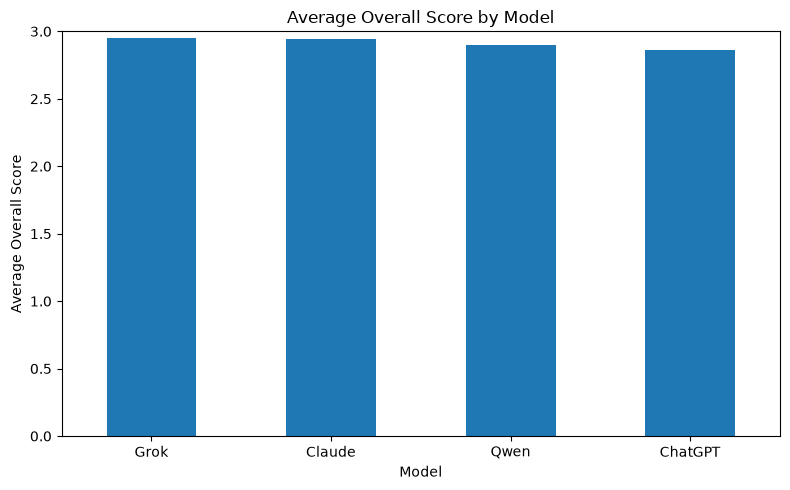

In [15]:
model_mean_scores = (
    analysis_df
    .groupby("model_name")["overall_score"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
model_mean_scores.plot(kind="bar")

plt.title("Average Overall Score by Model")
plt.xlabel("Model")
plt.ylabel("Average Overall Score")
plt.ylim(0, 3)
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "figures/average_overall_score_by_model.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Interpretation

Grok had the highest mean Overall Score (2.950), followed closely by Claude (2.942). Qwen had a mean score of 2.900, while ChatGPT had the lowest mean score (2.858).

The differences among the four models were small, particularly among Grok, Claude, and Qwen. These descriptive results should not by themselves be interpreted as evidence that one model is superior to another. The subsequent inferential analysis formally evaluates whether the observed differences are statistically significant.

### 2.2 Criterion-Level Model Comparison

This section compares the four models across accuracy, reasoning completeness, explanation clarity, and tutoring effectiveness.

In [16]:
score_columns = [
    "accuracy_score",
    "reasoning_completeness_score",
    "explanation_clarity_score",
    "tutoring_effectiveness_score"
]

criterion_summary = (
    analysis_df
    .groupby("model_name")[score_columns]
    .mean()
    .round(3)
)

criterion_summary

,accuracy_score,reasoning_completeness_score,explanation_clarity_score,tutoring_effectiveness_score
model_name,,,,
ChatGPT,3.0,2.933,2.933,2.567
Claude,3.0,3.000,2.867,2.900
Grok,3.0,2.967,2.933,2.900
Qwen,2.9,2.933,2.933,2.833


In [17]:
criterion_summary_display = criterion_summary.rename(
    columns={
        "accuracy_score": "Accuracy",
        "reasoning_completeness_score": "Reasoning Completeness",
        "explanation_clarity_score": "Explanation Clarity",
        "tutoring_effectiveness_score": "Tutoring Effectiveness"
    }
)

criterion_summary_display

,Accuracy,Reasoning Completeness,Explanation Clarity,Tutoring Effectiveness
model_name,,,,
ChatGPT,3.0,2.933,2.933,2.567
Claude,3.0,3.000,2.867,2.900
Grok,3.0,2.967,2.933,2.900
Qwen,2.9,2.933,2.933,2.833


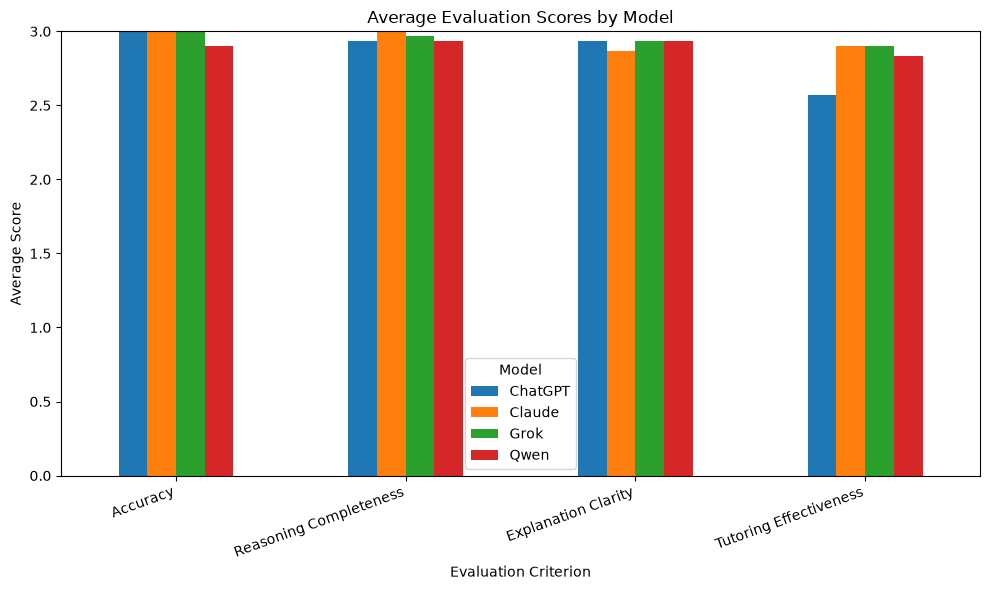

In [18]:
criterion_summary_display.T.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Evaluation Scores by Model")
plt.xlabel("Evaluation Criterion")
plt.ylabel("Average Score")
plt.ylim(0, 3)
plt.xticks(rotation=20, ha="right")
plt.legend(title="Model")
plt.tight_layout()

plt.savefig(
    "figures/criterion_scores_by_model.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Interpretation

Accuracy showed a strong ceiling effect. ChatGPT, Claude, and Grok each achieved a mean Accuracy score of 3.000, while Qwen averaged 2.900. Across all 120 responses, 117 received the maximum Accuracy score of 3, indicating that substantive correctness provided limited differentiation among the models. Under the scoring rubric, a maximum Accuracy score indicates that the response was substantively correct for the task and does not necessarily imply that every auxiliary statement was error-free.

Greater variation appeared in the other evaluation criteria. Claude achieved the highest Reasoning Completeness score (3.000), followed by Grok (2.967), while ChatGPT and Qwen both averaged 2.933. For Explanation Clarity, ChatGPT, Grok, and Qwen each averaged 2.933, while Claude averaged 2.867. Tutoring Effectiveness showed the largest separation among the criteria: Claude and Grok both averaged 2.900, followed by Qwen at 2.833 and ChatGPT at 2.567.

Overall, the criterion-level results show more variation in reasoning completeness, explanation clarity, and especially tutoring effectiveness than in accuracy. These differences are descriptive at this stage and do not by themselves establish statistical significance.

### 2.3 Distribution of Overall Scores

A boxplot is used to compare the distribution and consistency of overall scores across models.

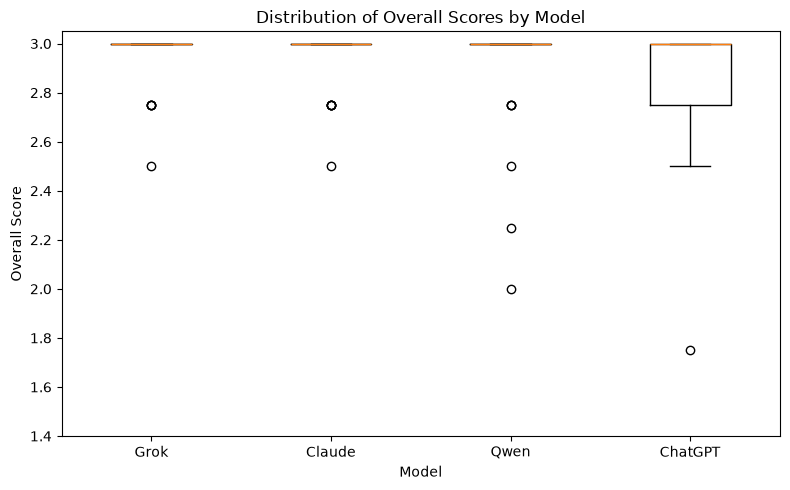

In [19]:
# Determine model order using mean overall score
model_order = (
    analysis_df
    .groupby("model_name")["overall_score"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

# Create one score series for each model
boxplot_data = [
    analysis_df.loc[
        analysis_df["model_name"] == model,
        "overall_score"
    ].dropna()
    for model in model_order
]

# Draw the boxplot
plt.figure(figsize=(8, 5))

plt.boxplot(
    boxplot_data,
    tick_labels=model_order
)

plt.title("Distribution of Overall Scores by Model")
plt.xlabel("Model")
plt.ylabel("Overall Score")
plt.ylim(1.4, 3.05)
plt.tight_layout()

plt.savefig(
    "figures/overall_score_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Interpretation

The boxplot shows a strong concentration of Overall Scores near the maximum value of 3.00. All four models had a median Overall Score of 3.00. For Grok, Claude, and Qwen, the central part of the distribution remained concentrated near the top of the scale.

ChatGPT showed the widest overall spread, with a minimum score of 1.75. Only 18 of its 30 responses received an Overall Score of 3.00, compared with 24 for Claude, 25 for Grok, and 24 for Qwen. This indicates greater question-to-question variability in ChatGPT's performance.

Qwen's scores were also mostly concentrated at 3.00, but several lower-scoring responses reduced its mean and increased its spread. These include the response errors identified during the final data review.

Overall, Grok, Claude, and Qwen were more concentrated near the maximum Overall Score, while ChatGPT showed greater variation across questions. However, the strong ceiling effect across all four models limits how much the score distributions can differentiate their performance.

### 2.4 Model Performance by Subject

This section compares the average Overall Score of each model across Statistics, Mathematics, and Python / Introductory Computer Science questions.

In [20]:
subject_model_summary = (
    analysis_df
    .groupby(["question_type", "model_name"])["overall_score"]
    .mean()
    .unstack()
    .round(3)
)

subject_model_summary

model_name,ChatGPT,Claude,Grok,Qwen
question_type,,,,
Mathematics,2.950,2.975,2.90,2.975
Python / Introductory Computer Science,2.725,3.000,3.00,2.750
Statistics,2.900,2.850,2.95,2.975


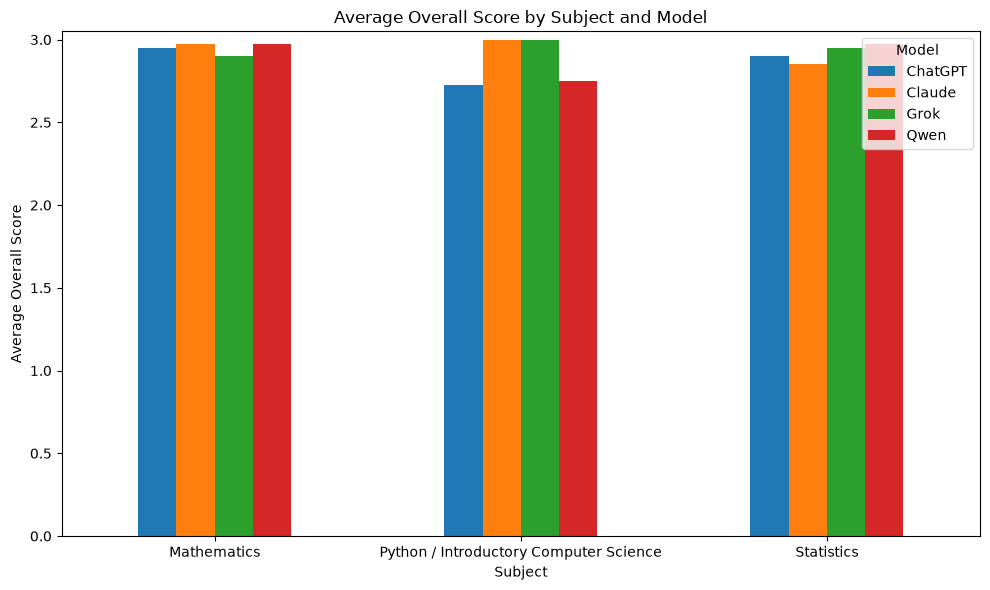

In [21]:
subject_model_summary.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Overall Score by Subject and Model")
plt.xlabel("Subject")
plt.ylabel("Average Overall Score")
plt.ylim(0, 3.05)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()

plt.savefig(
    "figures/subject_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Interpretation

Subject-level performance was high across all four models, although the descriptive rankings varied by subject.

In Statistics, Qwen achieved the highest mean Overall Score (2.975), followed by Grok (2.950), Claude (2.925), and ChatGPT (2.850). In Mathematics, Claude and Qwen shared the highest mean score (2.975), followed by Grok (2.900) and ChatGPT (2.850). In Python / Computer Science, Claude and Grok both achieved a mean score of 3.000, followed by Qwen at 2.750 and ChatGPT at 2.725.

No single model had the highest mean score across all three subjects. These subject-level results are descriptive and should be interpreted cautiously because each subject contains only 10 questions.

## 3. Learning Behavior and Error Analysis

### 3.1 Learning Behavior Analysis

This section examines how frequently each model demonstrates learning-support behaviors beyond providing a correct answer.

In [22]:
learning_columns = [
    "learning_transfer_support",
    "misconception_awareness",
    "self_check_support",
    "confidence_calibration",
    "cognitive_load_level"
]

analysis_df[learning_columns].head()

,learning_transfer_support,misconception_awareness,self_check_support,confidence_calibration,cognitive_load_level
0,yes,no,no,good,low
1,yes,no,yes,good,low
2,yes,no,no,good,low
3,yes,yes,yes,good,low
4,yes,no,no,good,medium


In [23]:
for column in learning_columns:
    print(f"\n{column}:")
    print(analysis_df[column].value_counts(dropna=False))


learning_transfer_support:
learning_transfer_support
yes        96
partial    22
no          2
Name: count, dtype: int64

misconception_awareness:
misconception_awareness
no     111
yes      9
Name: count, dtype: int64

self_check_support:
self_check_support
no     106
yes     14
Name: count, dtype: int64

confidence_calibration:
confidence_calibration
good       118
partial      2
Name: count, dtype: int64

cognitive_load_level:
cognitive_load_level
low       107
medium     13
Name: count, dtype: int64


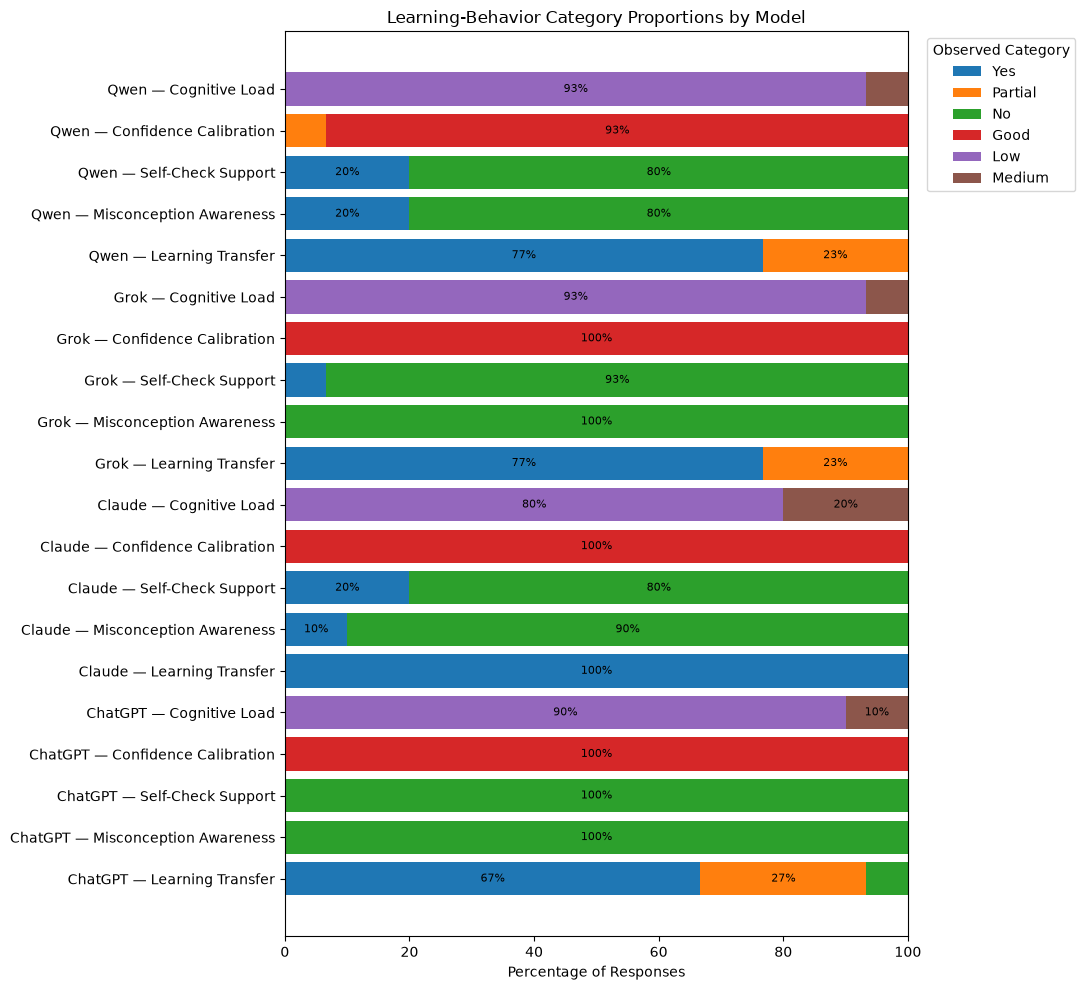

In [ ]:
# Learning-behavior category proportions by model
# Categories are displayed as proportions rather than converted to numeric scores.

behavior_columns = {
    "Learning Transfer": "learning_transfer_support",
    "Misconception Awareness": "misconception_awareness",
    "Self-Check Support": "self_check_support",
    "Confidence Calibration": "confidence_calibration",
    "Cognitive Load": "cognitive_load_level",
}

category_orders = {
    "Learning Transfer": ["yes", "partial", "no"],
    "Misconception Awareness": ["yes", "no"],
    "Self-Check Support": ["yes", "no"],
    "Confidence Calibration": ["good", "partial"],
    "Cognitive Load": ["low", "medium"],
}

rows = []

for model in analysis_df["model_name"].unique():
    model_data = analysis_df[analysis_df["model_name"] == model]

    for behavior_name, column_name in behavior_columns.items():
        proportions = (
            model_data[column_name]
            .value_counts(normalize=True)
            .reindex(category_orders[behavior_name], fill_value=0)
            .mul(100)
        )

        for category, percentage in proportions.items():
            rows.append({
                "model_name": model,
                "behavior": behavior_name,
                "category": category,
                "percentage": percentage,
            })

learning_behavior_proportions = pd.DataFrame(rows)

row_labels = [
    f"{model} — {behavior}"
    for model in analysis_df["model_name"].unique()
    for behavior in behavior_columns
]

all_categories = [
    "yes",
    "partial",
    "no",
    "good",
    "low",
    "medium",
]

plot_table = pd.DataFrame(
    0.0,
    index=row_labels,
    columns=all_categories,
)

for _, row in learning_behavior_proportions.iterrows():
    label = f"{row['model_name']} — {row['behavior']}"
    plot_table.loc[label, row["category"]] = row["percentage"]

fig, ax = plt.subplots(figsize=(11, 10))

left = np.zeros(len(plot_table))

for category in all_categories:
    values = plot_table[category].to_numpy()

    if values.sum() == 0:
        continue

    bars = ax.barh(
        plot_table.index,
        values,
        left=left,
        label=category.title(),
    )

    for bar, value, start in zip(bars, values, left):
        if value >= 8:
            ax.text(
                start + value / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.0f}%",
                ha="center",
                va="center",
                fontsize=8,
            )

    left += values

ax.set_xlim(0, 100)
ax.set_xlabel("Percentage of Responses")
ax.set_ylabel("")
ax.set_title("Learning-Behavior Category Proportions by Model")

ax.legend(
    title="Observed Category",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()

plt.savefig(
    "figures/learning_behavior_proportions.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Interpretation

The learning-behavior category-proportion figure shows how the observed learning-behavior labels were distributed across the four models for all 120 evaluated responses.

Learning Transfer Support was generally common across the models. Claude showed the highest proportion of responses labeled Yes, while ChatGPT showed a larger share of Partial responses. Grok and Qwen showed similar distributions, with most responses labeled Yes and the remainder primarily labeled Partial.

Misconception Awareness and Self-Check Support were much less common. Most responses from all four models were labeled No for these behaviors, although Qwen and Claude showed somewhat higher proportions of Yes responses than the other models in some categories.

Confidence Calibration was consistently strong across the dataset. Nearly all responses were labeled Good, with only a small number of Partial ratings.

Cognitive Load was predominantly labeled Low across all four models, with a smaller proportion of Medium ratings. Because cognitive load is a descriptive characteristic rather than a simple positive-performance scale, Low should not automatically be interpreted as better than Medium.

Overall, these results describe patterns in the manually assigned learning-behavior categories rather than validated educational measurements. The figure is intended for descriptive comparison only and should not be interpreted as a numerical ranking of the models.

### 3.2 Error Analysis

The final dataset contains three responses with recorded errors. Two were classified as Moderate errors. Q24–Qwen included a nonexistent B → E edge and therefore produced an incorrect adjacency list. Q28–Qwen correctly concluded that the overall time complexity was Θ(n²), but incorrectly stated that the third loop did not actually reverse the list.

Q29–Qwen was classified as a Minor conceptual error. Its main answer correctly identified the operations with Θ(n) complexity, but the final note incorrectly stated that adding a tail pointer would make deleting the last node O(1). In a singly linked list, deleting the last node still requires finding its predecessor.

The remaining 117 responses had no recorded error under the project's error-analysis framework. Errors were therefore uncommon in this benchmark, although the small number of identified errors should not be interpreted as evidence that the models are generally error-free.

Because only three responses had recorded errors, I did not create a separate error-distribution visualization. These cases are instead documented in the audit record and qualitative case studies.

In [29]:
print("Accuracy distribution:")
print(analysis_df["accuracy_score"].value_counts().sort_index())

print("\nError-type distribution:")
print(analysis_df["error_type"].fillna("none").value_counts())

print("\nSeverity distribution:")
print(analysis_df["severity_level"].fillna("none").value_counts())

Accuracy distribution:
accuracy_score
2      3
3    117
Name: count, dtype: int64

Error-type distribution:
error_type
none                    117
conceptual_error          2
hallucinated_concept      1
Name: count, dtype: int64

Severity distribution:
severity_level
none        117
Moderate      2
Minor         1
Name: count, dtype: int64


## 4. Exploratory Inferential Analysis

Because the benchmark was purposively constructed rather than randomly sampled, and responses were collected sequentially within each model conversation, the inferential analyses are treated as exploratory evidence within this benchmark rather than as population-level estimates of general model performance.

### 4.1 Analysis Overview

The statistical analysis examines whether the performance differences observed among the four models are supported beyond the descriptive results reported above. The analysis uses the audited primary-rater scores for all 120 responses, corresponding to 30 questions answered by each of the four models.

Because all four models answered the same set of questions, the observations are paired at the question level rather than treated as independent samples. The analysis first reports 95% confidence intervals to describe the uncertainty around each model's mean performance. Friedman tests are then used to test for systematic differences among the four models across the same questions. If an overall difference is detected, post-hoc pairwise comparisons are considered with adjustment for multiple testing.

The primary model-comparison analysis is based on the full primary-rater dataset. Inter-rater reliability is evaluated separately in Section 5 using the 32 double-rated responses.



### 4.2 95% Confidence Intervals

For each model, a 95% confidence interval was calculated around the mean Overall Score across the 30 questions. These intervals provide a measure of uncertainty around the observed mean performance and complement the descriptive model averages reported earlier.

The confidence intervals are reported descriptively and should not be interpreted as direct tests of pairwise differences between models. Formal paired comparisons are examined separately using the Friedman test in Section 4.3.

In [30]:
import numpy as np
import pandas as pd
from scipy import stats

primary = analysis_df.copy()
ci_results = []

for model, group in primary.groupby("model_name"):
    scores = group["overall_score"].dropna()

    n = len(scores)
    mean = scores.mean()
    sd = scores.std(ddof=1)
    se = sd / np.sqrt(n)

    t_critical = stats.t.ppf(0.975, df=n - 1)

    ci_lower = mean - t_critical * se
    ci_upper = mean + t_critical * se

    ci_results.append({
        "Model": model,
        "N": n,
        "Mean Overall Score": mean,
        "SD": sd,
        "SE": se,
        "95% CI Lower": ci_lower,
        "95% CI Upper": ci_upper
    })

overall_ci_df = pd.DataFrame(ci_results)

overall_ci_df.round(3)

,Model,N,Mean Overall Score,SD,SE,95% CI Lower,95% CI Upper
0,ChatGPT,30,2.858,0.252,0.046,2.764,2.952
1,Claude,30,2.942,0.126,0.023,2.895,2.989
2,Grok,30,2.950,0.121,0.022,2.905,2.995
3,Qwen,30,2.900,0.242,0.044,2.810,2.990


#### Results

The mean Overall Scores were 2.858 for ChatGPT, 2.942 for Claude, 2.950 for Grok, and 2.900 for Qwen. The corresponding 95% confidence intervals were [2.764, 2.952], [2.895, 2.989], [2.905, 2.995], and [2.810, 2.990], respectively.

All four models had high mean scores, and their confidence intervals overlapped substantially. Grok had the highest observed mean Overall Score, followed closely by Claude and Qwen, while ChatGPT had the lowest observed mean. The differences in the observed means were small relative to the uncertainty shown by the confidence intervals.

These confidence intervals are descriptive estimates of each model's mean performance rather than formal pairwise significance tests. Because the same 30 questions were answered by all four models, differences among models are evaluated using the paired Friedman test in the following section.

### 4.3 Friedman Test

Because all four models answered the same 30 questions, the model scores are paired rather than independent. A Friedman test was used to examine whether Overall Score differed systematically across the four models.

The null hypothesis was that the four models had the same distribution of Overall Scores across the 30 questions. The alternative hypothesis was that at least one model differed systematically from the others.

A significance level of α = 0.05 was used.

In [31]:
from scipy.stats import friedmanchisquare

# Arrange Overall Scores so that each row corresponds to the same question
overall_pivot = primary.pivot(
    index="question_id",
    columns="model_name",
    values="overall_score"
)

# Check the paired dataset
print("Shape:", overall_pivot.shape)
print("\nMissing values by model:")
print(overall_pivot.isna().sum())

print("\nModels:")
print(overall_pivot.columns.tolist())

# Friedman test
statistic, p_value = friedmanchisquare(
    overall_pivot["ChatGPT"],
    overall_pivot["Claude"],
    overall_pivot["Grok"],
    overall_pivot["Qwen"]
)

print("\nFriedman Test for Overall Score")
print(f"Chi-square statistic = {statistic:.4f}")
print(f"Degrees of freedom = {len(overall_pivot.columns) - 1}")
print(f"p-value = {p_value:.6f}")

Shape: (30, 4)

Missing values by model:
model_name
ChatGPT    0
Claude     0
Grok       0
Qwen       0
dtype: int64

Models:
['ChatGPT', 'Claude', 'Grok', 'Qwen']

Friedman Test for Overall Score
Chi-square statistic = 5.7214
Degrees of freedom = 3
p-value = 0.125979


#### Results

The Friedman test did not detect a statistically significant difference in Overall Score among the four models, χ²(3) = 5.721, p = 0.126.

Although the descriptive mean scores differed slightly across the four models, these differences were not statistically significant at the α = 0.05 level.

Therefore, the null hypothesis was not rejected. The results do not provide sufficient evidence that the four models differed systematically in Overall Score across the 30 paired questions.

In [32]:
# Effect size for the Friedman test: Kendall's W

n = overall_pivot.shape[0]
k = overall_pivot.shape[1]

kendalls_w = statistic / (n * (k - 1))

print(f"Kendall's W = {kendalls_w:.4f}")

Kendall's W = 0.0636


The corresponding Kendall's W was 0.0636, indicating a small overall effect. Together with the non-significant Friedman test, this suggests that differences in Overall Score among the four models were limited within this benchmark.

### 4.4 Criterion-Level Analysis

To examine whether the overall result masked differences in specific dimensions of response quality, separate Friedman tests were conducted for the four evaluation criteria: Accuracy, Reasoning Completeness, Explanation Clarity, and Tutoring Effectiveness.

Each test retained the paired structure of the dataset, with the four models compared on the same 30 questions. These criterion-level analyses were treated as secondary analyses to the primary Overall Score comparison.

In [33]:
from scipy.stats import friedmanchisquare
import pandas as pd

criteria = [
    "accuracy_score",
    "reasoning_completeness_score",
    "explanation_clarity_score",
    "tutoring_effectiveness_score"
]

criterion_friedman_results = []

for criterion in criteria:
    pivot = primary.pivot(
        index="question_id",
        columns="model_name",
        values=criterion
    )

    stat, p = friedmanchisquare(
        pivot["ChatGPT"],
        pivot["Claude"],
        pivot["Grok"],
        pivot["Qwen"]
    )

    n = pivot.shape[0]
    k = pivot.shape[1]
    w = stat / (n * (k - 1))

    criterion_friedman_results.append({
        "Criterion": criterion,
        "Chi-square": stat,
        "df": k - 1,
        "p-value": p,
        "Kendall's W": w
    })

criterion_friedman_df = pd.DataFrame(criterion_friedman_results)

criterion_friedman_df.round({
    "Chi-square": 3,
    "p-value": 4,
    "Kendall's W": 3
})

,Criterion,Chi-square,df,p-value,Kendall's W
0,accuracy_score,9.000,3,0.0293,0.100
1,reasoning_completeness_score,1.857,3,0.6026,0.021
2,explanation_clarity_score,1.385,3,0.7091,0.015
3,tutoring_effectiveness_score,13.602,3,0.0035,0.151


In [34]:
from statsmodels.stats.multitest import multipletests

# Apply Holm correction across the four criterion-level Friedman tests
raw_p_values = criterion_friedman_df["p-value"].values

reject, adjusted_p_values, _, _ = multipletests(
    raw_p_values,
    alpha=0.05,
    method="holm"
)

criterion_friedman_df["Holm-adjusted p"] = adjusted_p_values
criterion_friedman_df["Significant after Holm"] = reject

criterion_friedman_df.round({
    "Chi-square": 3,
    "p-value": 4,
    "Kendall's W": 3,
    "Holm-adjusted p": 4
})

,Criterion,Chi-square,df,p-value,Kendall's W,Holm-adjusted p,Significant after Holm
0,accuracy_score,9.000,3,0.0293,0.100,0.0879,False
1,reasoning_completeness_score,1.857,3,0.6026,0.021,1.0000,False
2,explanation_clarity_score,1.385,3,0.7091,0.015,1.0000,False
3,tutoring_effectiveness_score,13.602,3,0.0035,0.151,0.0140,True


#### Results

After applying the Holm correction across the four criterion-level Friedman tests, Tutoring Effectiveness was the only criterion that remained statistically significant, χ²(3) = 13.602, Holm-adjusted p = 0.014, with Kendall's W = 0.151.

Accuracy had a raw p-value of 0.029 but did not remain statistically significant after Holm correction (adjusted p = 0.088). Reasoning Completeness (adjusted p = 1.000) and Explanation Clarity (adjusted p = 1.000) were also not statistically significant after correction.

The criterion-level results therefore provide evidence of model differences in Tutoring Effectiveness within this benchmark. Post-hoc paired comparisons were conducted for this criterion to examine which model pairs differed.

### 4.5 Post-Hoc Pairwise Comparisons

Because the Friedman test identified a significant model effect for Tutoring Effectiveness after Holm correction, post-hoc paired Wilcoxon signed-rank tests were conducted to identify which model pairs differed.

All six pairwise model comparisons were examined. Holm correction was applied to the six resulting p-values to control for multiple comparisons.

In [35]:
from itertools import combinations
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import pandas as pd

# Paired Tutoring Effectiveness scores
tutoring_pivot = primary.pivot(
    index="question_id",
    columns="model_name",
    values="tutoring_effectiveness_score"
)

models = ["ChatGPT", "Claude", "Grok", "Qwen"]

pairwise_results = []

for model1, model2 in combinations(models, 2):
    scores1 = tutoring_pivot[model1]
    scores2 = tutoring_pivot[model2]

    differences = scores1 - scores2
    nonzero_n = (differences != 0).sum()

    # Wilcoxon signed-rank test
    if nonzero_n == 0:
        statistic_w = 0.0
        p_value = 1.0
    else:
        statistic_w, p_value = wilcoxon(
            scores1,
            scores2,
            alternative="two-sided",
            zero_method="wilcox"
        )

    pairwise_results.append({
        "Comparison": f"{model1} vs {model2}",
        "Mean 1": scores1.mean(),
        "Mean 2": scores2.mean(),
        "Non-zero pairs": nonzero_n,
        "Wilcoxon W": statistic_w,
        "Raw p": p_value
    })

pairwise_df = pd.DataFrame(pairwise_results)

# Holm correction across the six post-hoc comparisons
reject, adjusted_p, _, _ = multipletests(
    pairwise_df["Raw p"],
    alpha=0.05,
    method="holm"
)

pairwise_df["Holm-adjusted p"] = adjusted_p
pairwise_df["Significant after Holm"] = reject

pairwise_df.round({
    "Mean 1": 3,
    "Mean 2": 3,
    "Wilcoxon W": 3,
    "Raw p": 4,
    "Holm-adjusted p": 4
})

,Comparison,Mean 1,Mean 2,Non-zero pairs,Wilcoxon W,Raw p,Holm-adjusted p,Significant after Holm
0,ChatGPT vs Claude,2.567,2.900,15,22.5,0.0184,0.0921,False
1,ChatGPT vs Grok,2.567,2.900,11,5.5,0.0075,0.0452,True
2,ChatGPT vs Qwen,2.567,2.833,12,13.0,0.0209,0.0921,False
3,Claude vs Grok,2.900,2.900,4,5.0,1.0000,1.0000,False
4,Claude vs Qwen,2.900,2.833,6,7.0,0.4142,0.9519,False
5,Grok vs Qwen,2.900,2.833,4,2.5,0.3173,0.9519,False


#### Results

Before multiple-comparison correction, ChatGPT differed from Claude (p = 0.018), Grok (p = 0.008), and Qwen (p = 0.021) in Tutoring Effectiveness.

After applying the Holm correction across the six pairwise comparisons, only the difference between ChatGPT and Grok remained statistically significant (Holm-adjusted p = 0.045). Grok had a higher mean Tutoring Effectiveness score (M = 2.900) than ChatGPT (M = 2.567). None of the other pairwise comparisons remained statistically significant after correction.

The significant ChatGPT–Grok comparison was based on 11 non-zero paired differences, with the remaining question-level ratings tied for this pair. This result provides evidence of a difference in Tutoring Effectiveness between ChatGPT and Grok within this benchmark, but should not be interpreted as evidence of general model superiority.

### 4.6 Statistical Analysis Summary

The inferential analyses provided limited evidence of systematic performance differences among the four evaluated models.

For Overall Score, the model means were high and closely clustered. Grok had the highest mean Overall Score (M = 2.950), followed by Claude (M = 2.942), Qwen (M = 2.900), and ChatGPT (M = 2.858). The corresponding 95% confidence intervals overlapped substantially. The Friedman test did not detect a statistically significant overall difference among the four models, χ²(3) = 5.721, p = 0.126. The associated Kendall's W was 0.064, indicating a small overall effect.

At the criterion level, Tutoring Effectiveness was the only criterion that remained statistically significant after Holm correction, χ²(3) = 13.602, Holm-adjusted p = 0.014, with Kendall's W = 0.151. Accuracy had a raw p-value below 0.05 but was not statistically significant after Holm correction (adjusted p = 0.088). Reasoning Completeness and Explanation Clarity were also not statistically significant after correction.

Post-hoc Wilcoxon signed-rank tests were therefore conducted for Tutoring Effectiveness. After Holm correction across the six pairwise comparisons, only the ChatGPT–Grok comparison remained statistically significant (Holm-adjusted p = 0.045). Grok had a higher mean Tutoring Effectiveness score (M = 2.900) than ChatGPT (M = 2.567). No other pairwise comparison remained statistically significant after correction. This result should be interpreted as limited benchmark-specific evidence rather than as a robust general ranking of the two models.

Overall, the four models had similar aggregate Overall Scores within this 30-question benchmark, while a more specific difference appeared in Tutoring Effectiveness. These findings should be interpreted within the scope of the current benchmark rather than as evidence of general superiority of any model.

## 5. Inter-Rater Reliability Analysis


### 5.1 Second-Rater Procedure

To assess the consistency of the evaluation framework, a second rater independently evaluated a subset of 32 model responses covering eight complete question blocks.

For each selected question, the second rater was provided with the question ID and question text, the reference answer, the four model responses, and the definitions used for the evaluation criteria, error analysis, and learning-behavior annotations. Ratings were recorded independently in a separate Excel worksheet. The second rater did not have access to the primary rater's completed scores or annotations during the rating process. Model identities were visible during the rating process, so potential model-related expectation bias cannot be ruled out.

### 5.2 Sample Selection

The reliability subset consisted of eight complete question blocks: Q4, Q6, Q10, Q14, Q17, Q21, Q27, and Q29. All four model responses were included for each selected question, giving 32 responses in total, or 26.7% of the full 120-response dataset.

Complete question blocks were used so that all four models were represented equally within each selected question. The subset was selected purposively to provide coverage across the three subject areas and to include responses showing different scoring patterns in the primary evaluation. It should therefore be interpreted as a structured reliability subset rather than a random sample of the full dataset.

Q24 and Q28 were not included because they had already been identified as failure cases during the earlier audit and were reviewed separately before the second-rater subset was finalized. Q29 was included in the subset and rated by the second rater before the later final audit identified an additional issue in the Qwen response. I retained Q29 in the reliability analysis rather than changing the subset after the second-rater ratings had already been collected. The reliability results should therefore be interpreted only as a check within this purposively selected subset.

### 5.3 Agreement Analysis

Exact agreement was calculated for each evaluation criterion by comparing the primary and second raters' scores for the same 32 responses. A rating pair was counted as an exact agreement only when both raters assigned the same score on the 0–3 scale.

In [36]:
# Load the public-safe paired second-rater dataset
matched = pd.read_csv("data/public_second_rater_scores.csv")

print("Public second-rater dataset shape:", matched.shape)

print("\nColumns:")
print(matched.columns.tolist())

Public second-rater dataset shape: (32, 10)

Columns:
['question_id', 'model_name', 'accuracy_score_primary', 'accuracy_score_second', 'reasoning_completeness_score_primary', 'reasoning_completeness_score_second', 'explanation_clarity_score_primary', 'explanation_clarity_score_second', 'tutoring_effectiveness_score_primary', 'tutoring_effectiveness_score_second']


In [37]:
# Calculate exact agreement and average absolute difference for each criterion

criteria = [
    "accuracy_score",
    "reasoning_completeness_score",
    "explanation_clarity_score",
    "tutoring_effectiveness_score"
]

agreement_results = []

for criterion in criteria:
    primary_col = f"{criterion}_primary"
    second_col = f"{criterion}_second"

    exact_agreement_count = (
        matched[primary_col] == matched[second_col]
    ).sum()

    exact_agreement_pct = (
        exact_agreement_count / len(matched) * 100
    )

    aad = (
        matched[primary_col] - matched[second_col]
    ).abs().mean()

    agreement_results.append({
        "Criterion": criterion,
        "Exact Agreement": exact_agreement_count,
        "Exact Agreement (%)": exact_agreement_pct,
        "Average Absolute Difference": aad
    })

agreement_df = pd.DataFrame(agreement_results)

agreement_df

,Criterion,Exact Agreement,Exact Agreement (%),Average Absolute Difference
0,accuracy_score,31,96.875,0.03125
1,reasoning_completeness_score,32,100.000,0.00000
2,explanation_clarity_score,29,90.625,0.09375
3,tutoring_effectiveness_score,28,87.500,0.12500


#### Agreement Results

Agreement between the two raters was high across all four scoring criteria. Reasoning Completeness showed complete agreement, with identical ratings for all 32 responses (100%). Accuracy agreed on 31 of 32 responses (96.9%), with an average absolute difference of 0.031.

For Explanation Clarity, the raters agreed on 29 of 32 responses (90.6%), with an average absolute difference of 0.094. Tutoring Effectiveness showed agreement on 28 of 32 responses (87.5%), with an average absolute difference of 0.125.

Overall, the two raters gave similar scores across the selected responses. Most disagreements occurred in Explanation Clarity and Tutoring Effectiveness, while Accuracy and Reasoning Completeness showed higher agreement.

### 5.4 Weighted Cohen's Kappa

Weighted Cohen's kappa was used to assess agreement between the primary and second raters while accounting for agreement that could occur by chance. Because the four evaluation criteria were scored on an ordered 0–3 scale, quadratic weights were used so that larger scoring disagreements received greater penalties than adjacent-score disagreements.

Kappa was calculated separately for Accuracy, Reasoning Completeness, Explanation Clarity, and Tutoring Effectiveness across the 32 double-rated responses.

In [38]:
from sklearn.metrics import cohen_kappa_score
import pandas as pd
import numpy as np

criteria = [
    "accuracy_score",
    "reasoning_completeness_score",
    "explanation_clarity_score",
    "tutoring_effectiveness_score"
]

kappa_results = []

for criterion in criteria:
    primary_col = f"{criterion}_primary"
    second_col = f"{criterion}_second"

    rater1 = matched[primary_col]
    rater2 = matched[second_col]

    # Kappa requires variation in the ratings.
    # If both raters assign only one category, kappa is not estimable.
    if rater1.nunique() == 1 and rater2.nunique() == 1:
        kappa = np.nan
    else:
        kappa = cohen_kappa_score(
            rater1,
            rater2,
            weights="quadratic"
        )

    kappa_results.append({
        "Criterion": criterion,
        "Quadratic Weighted Kappa": kappa
    })

kappa_df = pd.DataFrame(kappa_results)

kappa_df

,Criterion,Quadratic Weighted Kappa
0,accuracy_score,0.000000
1,reasoning_completeness_score,NaN
2,explanation_clarity_score,0.520000
3,tutoring_effectiveness_score,0.272727


#### Kappa Results

Quadratic weighted Cohen's kappa was 0.000 for Accuracy, 0.520 for Explanation Clarity, and 0.273 for Tutoring Effectiveness. Kappa could not be estimated for Reasoning Completeness because all 32 ratings were identical.

The Accuracy result illustrates an important limitation of kappa in this subset. The raters agreed on 31 of 32 responses, but the scores were highly concentrated, leaving very little variation for the statistic to distinguish observed agreement from agreement expected by chance. The kappa value of 0.000 should therefore be considered alongside the 96.9% exact agreement rather than interpreted by itself as evidence of poor agreement.

For Explanation Clarity and Tutoring Effectiveness, exact agreement was 90.6% and 87.5%, respectively, while their weighted kappa values were lower. All disagreements across the four criteria were only one point on the 0–3 scale. Together, the exact-agreement and kappa results show that the raters usually assigned the same or nearby scores, while also showing the limitations of chance-corrected agreement measures when scores are highly concentrated.

### 5.5 Disagreement Review

To better understand the differences between the two raters, all disagreements in the four scoring criteria were reviewed individually. The review focused on the size and direction of each disagreement and on whether the differences appeared to reflect substantive conflicts within the rubric.

Across the 32 double-rated responses, eight criterion-level disagreements were identified. All differed by only one point on the 0–3 scale.

In [39]:
score_criteria = [
    "accuracy_score",
    "reasoning_completeness_score",
    "explanation_clarity_score",
    "tutoring_effectiveness_score"
]

disagreements = []

for criterion in score_criteria:
    primary_col = f"{criterion}_primary"
    second_col = f"{criterion}_second"

    diff_rows = matched[
        matched[primary_col] != matched[second_col]
    ]

    for _, row in diff_rows.iterrows():
        disagreements.append({
            "Question": row["question_id"],
            "Model": row["model_name"],
            "Criterion": criterion,
            "Primary Rater": row[primary_col],
            "Second Rater": row[second_col],
            "Difference": abs(row[primary_col] - row[second_col])
        })

disagreement_df = pd.DataFrame(disagreements)

disagreement_df

,Question,Model,Criterion,Primary Rater,Second Rater,Difference
0,29,Qwen,accuracy_score,2,3,1
1,6,Claude,explanation_clarity_score,2,3,1
2,17,Grok,explanation_clarity_score,2,3,1
3,29,ChatGPT,explanation_clarity_score,3,2,1
4,10,ChatGPT,tutoring_effectiveness_score,2,3,1
5,21,ChatGPT,tutoring_effectiveness_score,2,3,1
6,29,Claude,tutoring_effectiveness_score,3,2,1
7,29,Qwen,tutoring_effectiveness_score,2,3,1


#### Disagreement Patterns

Eight criterion-level disagreements were identified across the 32 double-rated responses. One occurred in Accuracy, three in Explanation Clarity, and four in Tutoring Effectiveness. No disagreement occurred in Reasoning Completeness, and every disagreement was limited to a one-point difference.

The Accuracy disagreement occurred for Q29 Qwen, where the primary rater assigned 2 and the second rater assigned 3.

For Explanation Clarity, the disagreements occurred for Q6 Claude, Q17 Grok, and Q29 ChatGPT. The second rater assigned a higher score in two cases and a lower score in one case.

For Tutoring Effectiveness, the disagreements occurred for Q10 ChatGPT, Q21 ChatGPT, Q29 Claude, and Q29 Qwen. The second rater assigned a higher score in three cases and a lower score in one case.

Overall, the disagreements were small and were more common in Explanation Clarity and Tutoring Effectiveness than in the other two criteria. The direction of the differences was mixed, although the second rater assigned the higher score in most of the disagreement cases.

### 5.6 Reliability Interpretation

The second-rater analysis showed generally high exact agreement with the primary rater, although the level of agreement differed across the four evaluation criteria.

Reasoning Completeness had 100% exact agreement across all 32 double-rated responses. Accuracy had 96.9% exact agreement, with only one disagreement. Kappa could not be estimated for Reasoning Completeness because the ratings lacked variation, while Accuracy produced a weighted kappa of 0.000 despite its high exact agreement. These results reflect the highly concentrated score distribution in the selected subset and show why the kappa values should be interpreted alongside the exact-agreement results.

Explanation Clarity had 90.6% exact agreement with a weighted kappa of 0.520, while Tutoring Effectiveness had 87.5% exact agreement with a weighted kappa of 0.273. All disagreements across the four criteria were limited to one point on the 0–3 scale.

Eight criterion-level disagreements were identified: one in Accuracy, three in Explanation Clarity, and four in Tutoring Effectiveness. The second rater assigned the higher score in most of these cases, but the small number of disagreements does not support a broader conclusion about systematic scoring differences between the raters.

Overall, the second-rater results suggest relatively high exact agreement within the selected subset. Because the reliability analysis was based on a purposively selected subset of 32 responses rather than the full dataset, these results should be interpreted as a reliability check for this subset rather than as a precise estimate for all 120 responses.

## 6. Final Findings and Discussion

### 6.1 Overall Model Performance

Overall model performance was high and closely clustered. Grok achieved the highest mean Overall Score (M = 2.950), followed by Claude (M = 2.942), Qwen (M = 2.900), and ChatGPT (M = 2.858). These descriptive differences were small and should not be interpreted as evidence that one model was generally superior.

The Friedman test found no statistically significant difference in Overall Score among the four models. The 95% confidence intervals for the four model means also overlapped substantially.

Taken together, the results suggest that the four models performed similarly in aggregate on this 30-question benchmark. Although Grok and Claude had slightly higher descriptive mean scores, the analysis did not provide sufficient evidence of a systematic overall performance difference among the models.

### 6.2 Differences Across Evaluation Criteria

Differences among the models became more apparent when performance was examined by individual evaluation criterion rather than by Overall Score alone.

Accuracy showed a strong ceiling effect, with 117 of the 120 responses receiving the maximum score. Consistent with this limited variation, the criterion-level Friedman analysis did not identify a statistically significant model difference in Accuracy. Reasoning Completeness and Explanation Clarity likewise showed no statistically significant differences among the four models after correction for multiple testing.

Tutoring Effectiveness was the only criterion for which the model effect remained statistically significant after Holm correction, χ²(3) = 13.602, Holm-adjusted p = 0.014, with Kendall's W = 0.151. This suggests that differences among the models were more detectable in the quality of their tutoring support than in basic answer accuracy.

Post-hoc Wilcoxon signed-rank tests showed that only the ChatGPT–Grok comparison remained statistically significant after Holm correction (adjusted p = 0.045). Grok received a higher mean Tutoring Effectiveness score (M = 2.900) than ChatGPT (M = 2.567). The remaining pairwise comparisons were not statistically significant after correction.

### 6.3 Subject-Level Performance

Model performance also varied across the three subject areas. The subject-level results were treated as descriptive because each subject contained only 10 questions, providing a relatively small basis for separate inferential comparisons.

Qwen achieved the highest mean score in Statistics, while Claude and Qwen tied for the highest mean score in Mathematics. In Python, Claude and Grok achieved the highest mean score. No single model therefore achieved the highest mean performance across all three subject areas.

This pattern suggests that model performance may depend partly on the type of academic task being evaluated. The absence of a consistently dominant model across Statistics, Mathematics, and Python also provides additional context for the non-significant overall Friedman result. Rather than indicating a clear general ranking, the results suggest that relative model strengths may vary across subject areas.

Because the subject-level comparisons are based on only 10 questions per subject and were not tested separately for statistical significance, these patterns should be interpreted as descriptive findings rather than evidence of subject-specific model superiority.

### 6.4 Learning-Support Behaviors

The learning-behavior analysis revealed differences among the models that were not fully captured by the four primary evaluation scores. These tags were used descriptively to characterize how the models supported learning beyond simply producing correct answers.

Claude, Grok, and Qwen showed stronger evidence of learning-transfer support than ChatGPT, with Claude receiving the highest average score on this dimension. Misconception awareness was relatively uncommon overall, although Qwen showed the highest average level, followed by Claude. Qwen also showed the strongest self-check support, while this behavior appeared less frequently in responses from the other models.

Confidence calibration showed little differentiation among the four models, with all models receiving similarly high average ratings. Cognitive-load ratings were also relatively similar across models, suggesting that large differences in the manageability of response complexity were not evident in this benchmark.

Taken together, these patterns suggest that models with similar overall performance may still differ in how they support the learning process. In particular, behaviors such as encouraging transfer, anticipating misconceptions, and supporting self-checking provide additional information about an AI system's potential value as a learning assistant that is not captured by answer accuracy alone.

### 6.5 Error Patterns and Individual Failure Cases

Substantive errors were uncommon in the final evaluated dataset. Of the 120 model responses, 117 received the maximum Accuracy score, producing a pronounced ceiling effect in this criterion. Only a small number of responses were therefore represented in the formal error categories.

However, reviewing individual responses showed that answer correctness alone did not always capture the quality of the explanation. Some responses reached the correct final answer or selected the correct option while still including a conceptual or explanatory problem. For example, an additional explanation could introduce an incorrect claim even when the main answer was correct. This is why reasoning and tutoring quality were evaluated separately from final-answer accuracy.

The small number of substantive errors limits broad conclusions about model-specific error tendencies. The identified cases are therefore more useful as individual failure cases than as evidence of stable error patterns for particular models.

Overall, the error analysis shows the value of using multiple evaluation criteria. On a benchmark where most responses were correct, differences in reasoning, explanation, tutoring behavior, and individual failure cases provided information that would have been missed by looking at accuracy alone.

### 6.6 Reliability of the Evaluation Framework

The second-rater analysis provided additional information about how consistently the evaluation framework was applied. A purposively selected subset of 32 responses was independently evaluated by a second rater using the same scoring criteria.

Reasoning Completeness had complete agreement across all 32 responses. Accuracy had 31 of 32 exact agreements (96.9%), Explanation Clarity had 29 of 32 (90.6%), and Tutoring Effectiveness had 28 of 32 (87.5%).

The quadratic weighted kappa values were 0.000 for Accuracy, 0.520 for Explanation Clarity, and 0.273 for Tutoring Effectiveness. Kappa could not be estimated for Reasoning Completeness because the ratings lacked variation. The low kappa for Accuracy should be interpreted cautiously because only one disagreement occurred and the score distribution was highly restricted.

Across the four criteria, eight criterion-level disagreements were identified, and all were limited to one point on the 0–3 scale. The disagreements were more common in Explanation Clarity and Tutoring Effectiveness than in Accuracy or Reasoning Completeness.

Overall, the second-rater results show relatively high exact agreement within the selected subset, while also showing greater rater discretion in some of the more interpretive criteria. Because the reliability analysis used a purposively selected subset of 32 responses rather than the complete dataset, these results describe agreement within this subset rather than providing a precise estimate of reliability across all 120 responses.

### 6.7 Overall Interpretation

The results of this project do not support a simple ranking of the four models. All four achieved high Overall Scores, and the primary Friedman test did not find a statistically significant overall difference across the 30 questions.

The strongest difference appeared in Tutoring Effectiveness. This was the only evaluation criterion that remained statistically significant after correction for multiple testing, and the post-hoc analysis identified a significant difference between ChatGPT and Grok within this benchmark. At the same time, the strong ceiling effect in Accuracy shows that correctness alone provided limited separation among the models.

The qualitative results add context to these numerical findings. Responses with similar scores could still differ in how clearly they explained a concept, how much useful support they provided, or whether an additional explanation introduced a misleading claim. The individual failure cases also show why evaluating only the final answer can miss important differences in response quality.

Overall, the benchmark suggests that these models were generally strong on the evaluated introductory questions, but their usefulness as study assistants depended on more than correctness alone. The findings are limited to this 30-question benchmark and should not be interpreted as evidence that any one model is generally superior.

## 7. Limitations and Future Work

### 7.1 Limitations

Several limitations should be considered when interpreting the results of this study.

First, the benchmark contained 30 questions, with 10 questions from each of the three subject areas. Although this design allowed the same questions to be evaluated across all four models, the relatively small benchmark limits the generalizability of the findings. The subject-level comparisons are especially exploratory because each subject was represented by only 10 questions.

Second, model performance was strongly concentrated near the upper end of the scoring scale. In particular, 117 of the 120 responses received the maximum Accuracy score. This ceiling effect reduced the ability of Accuracy, and to some extent the aggregate Overall Score, to distinguish among high-performing models. The use of a coarse 0–3 scoring scale also produced many tied ratings, which can reduce the sensitivity of statistical comparisons.

Third, most of the dataset was evaluated by a single primary rater, and model identities were visible during the primary scoring process. The primary evaluation was therefore not blinded, so potential model-related expectation bias cannot be ruled out. A second rater independently evaluated a purposively selected subset of 32 responses, representing 26.7% of the full response dataset. Model identities were also visible during the second-rater rating process. Although exact agreement was high, particularly for Accuracy and Reasoning Completeness, the subset was not randomly sampled and does not provide a complete independent evaluation of all 120 responses. Explanation Clarity and Tutoring Effectiveness also showed greater rater discretion than the more objective criteria.

The Overall Score was calculated as an equal-weight average of the four evaluation criteria. This provides a simple summary measure, but the equal weighting was a methodological choice rather than an empirically validated weighting scheme. Differences among the individual criteria may therefore be obscured by the aggregate score, which is why criterion-level results were also examined separately.

Fourth, some analyses were descriptive rather than inferential. In particular, subject-level patterns and learning-behavior tags were used to identify possible differences among models but were not treated as evidence of statistically significant model effects. These results should therefore be interpreted as exploratory patterns that may motivate further study. The learning-behavior tags were manually assigned and converted to numerical values for descriptive visualization; they should not be interpreted as validated educational measurements.

Fifth, the evaluated systems represent specific model versions, settings, and access interfaces at the time the responses were collected. AI models and consumer-facing systems can change over time, so the results should not be assumed to describe future versions of the same products.

Finally, the current benchmark and associated materials require source and permission review before any public release. The internal research analysis can be conducted independently of this issue, but public distribution of question materials should occur only after their release status has been verified.

### 7.2 Future Work

Future versions of the study could expand the benchmark by including a larger number and wider variety of questions within each subject. Increasing the number of questions would improve the ability to evaluate subject-specific patterns and reduce the influence of individual questions on model-level results.

The benchmark could also include more challenging or deliberately diagnostic questions. Because Accuracy showed a strong ceiling effect in the current dataset, questions requiring deeper reasoning, multi-step problem solving, misconception detection, debugging, or explanation of incorrect student work may provide greater differentiation among high-performing models.

Future evaluations could strengthen the reliability design by independently double-rating a larger or randomly selected portion of the response dataset. Additional refinement of the rubric may also be useful for the more interpretive dimensions, particularly Explanation Clarity and Tutoring Effectiveness, where the second-rater analysis showed greater scoring variability.

The learning-behavior framework could also be developed further. Behaviors such as learning transfer, misconception awareness, self-check support, confidence calibration, and cognitive load could be operationalized with more detailed scoring rules or evaluated through additional raters. This would allow future work to examine these educational behaviors more systematically rather than primarily as descriptive indicators.

Finally, future studies could extend the evaluation beyond static model responses. For example, multi-turn tutoring interactions could be examined to determine how models respond to student confusion, incorrect intermediate answers, follow-up questions, and requests for alternative explanations. Such evaluations may provide a more realistic measure of how AI systems function as interactive study assistants.

## 8. Final Notebook Validation

This final validation checks the basic structure and completeness of the dataset used in the Research Version 1.0 analysis.

In [40]:
import pandas as pd

responses_df = pd.read_csv("data/public_analysis_scores.csv")
second_rater_df = pd.read_csv("data/public_second_rater_scores.csv")

questions_df = (
    responses_df[
        ["question_id", "question_type", "difficulty_level"]
    ]
    .drop_duplicates()
)

print("RESEARCH 1.0 PUBLIC NOTEBOOK VALIDATION")
print("-" * 45)

print("Questions:", len(questions_df))
print("Total responses:", len(responses_df))
print("Unique question IDs:", responses_df["question_id"].nunique())
print("Number of models:", responses_df["model_name"].nunique())

print("\nResponses per model:")
print(responses_df["model_name"].value_counts().sort_index())

print("\nQuestions per subject:")
print(questions_df["question_type"].value_counts().sort_index())

print("\nMissing primary scores:")
score_cols = [
    "accuracy_score",
    "reasoning_completeness_score",
    "explanation_clarity_score",
    "tutoring_effectiveness_score",
    "overall_score"
]
print(responses_df[score_cols].isna().sum())

print("\nDuplicate question-model pairs:")
print(
    responses_df.duplicated(
        subset=["question_id", "model_name"]
    ).sum()
)

print("\nSecond-rater responses:", len(second_rater_df))

print("\nSecond-rater duplicate question-model pairs:")
print(
    second_rater_df.duplicated(
        subset=["question_id", "model_name"]
    ).sum()
)

RESEARCH 1.0 PUBLIC NOTEBOOK VALIDATION
---------------------------------------------
Questions: 30
Total responses: 120
Unique question IDs: 30
Number of models: 4

Responses per model:
model_name
ChatGPT    30
Claude     30
Grok       30
Qwen       30
Name: count, dtype: int64

Questions per subject:
question_type
Mathematics                               10
Python / Introductory Computer Science    10
Statistics                                10
Name: count, dtype: int64

Missing primary scores:
accuracy_score                  0
reasoning_completeness_score    0
explanation_clarity_score       0
tutoring_effectiveness_score    0
overall_score                   0
dtype: int64

Duplicate question-model pairs:
0

Second-rater responses: 32

Second-rater duplicate question-model pairs:
0


### 8.1 Reproducibility

The quantitative analyses and figures in this notebook can be reproduced using the public-safe derived datasets included in this repository.

1. Open `notebook/ai_tutor_analysis.ipynb` in a Python environment.
2. Install the required Python packages listed in `requirements.txt`.
3. Run the notebook from beginning to end.
4. The main quantitative analyses use `data/public_analysis_scores.csv`.
5. The inter-rater reliability analyses use `data/public_second_rater_scores.csv`.
6. The notebook validates the public datasets before analysis and regenerates the figures stored in `figures/`.

The public derived datasets contain scores, model identifiers, question IDs, subject and difficulty metadata, and selected categorical annotations needed for analysis. They do not contain the original question text, raw model responses, or private reference-answer materials.

The analysis notebook uses relative file paths, so the repository structure should be preserved when running the notebook.